## Customer Conversion Prediction & Marketing Optimization using Machine Learning

Business Problem: A bank wants to improve its telemarketing campaigns by predicting which customers are most likely to subscribe to a term deposit, reducing cost and increasing conversion rate.

In [45]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [46]:
data = pd.read_csv("../Data/bank.csv")
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [48]:
data["deposit"].value_counts(normalize=True)

deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64

In [49]:
data["poutcome"].value_counts()

poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64

In [50]:
data["contact"].value_counts()

contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

In [51]:
data["job"].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

In [52]:
data["education"].value_counts()

education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

In [53]:
data["default"].value_counts()

default
no     10994
yes      168
Name: count, dtype: int64

In [54]:
data["housing"].value_counts()

housing
no     5881
yes    5281
Name: count, dtype: int64

In [55]:
data["loan"].value_counts()

loan
no     9702
yes    1460
Name: count, dtype: int64

In [56]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [57]:
# Checking for duplicates 
data.duplicated().any()


np.False_

In [58]:
# Converting the target variable into a binary target 
data["deposit"] = data["deposit"].map({"yes" : 1, "no" : 0})
data["deposit"]

0        1
1        1
2        1
3        1
4        1
        ..
11157    0
11158    0
11159    0
11160    0
11161    0
Name: deposit, Length: 11162, dtype: int64

In [59]:
# Selecting customers who subscribed to a deposit
data[data["deposit"] == 1]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5284,78,retired,divorced,primary,no,1389,no,no,cellular,8,apr,335,1,-1,0,unknown,1
5285,30,management,single,tertiary,no,398,no,no,cellular,27,oct,102,1,180,3,success,1
5286,69,retired,divorced,tertiary,no,247,no,no,cellular,22,apr,138,2,-1,0,unknown,1
5287,48,entrepreneur,married,secondary,no,0,no,yes,cellular,28,jul,431,2,-1,0,unknown,1


#### Analyzing relationships of conversion

<Axes: xlabel='deposit', ylabel='count'>

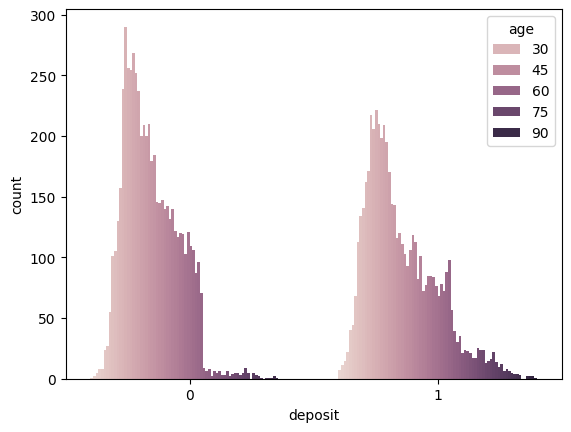

In [60]:
sns.countplot(x="deposit", hue="age", data=data)

In [61]:
# Balance vs conversion rate
data.groupby("deposit")["balance"].mean()

deposit
0    1280.227141
1    1804.267915
Name: balance, dtype: float64

<Axes: xlabel='balance', ylabel='Count'>

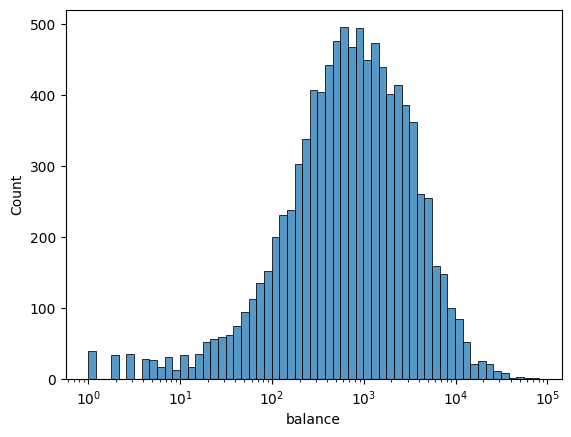

In [62]:
sns.histplot(data["balance"], log_scale=True)

In [63]:
# Balance has big outliers
data["balance"].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

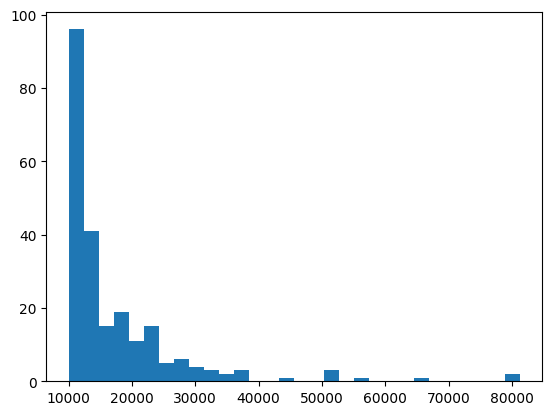

In [64]:
# Amount of people with a balance > 10000
plt.hist(data[data["balance"] > 10000]["balance"], bins=30)
plt.show()

In [65]:
# Dropping outliers
print((data["balance"] > 10000).sum(),  "outliers being dropped")
data = data[data["balance"] < 10000]

228 outliers being dropped


<Axes: xlabel='balance', ylabel='Count'>

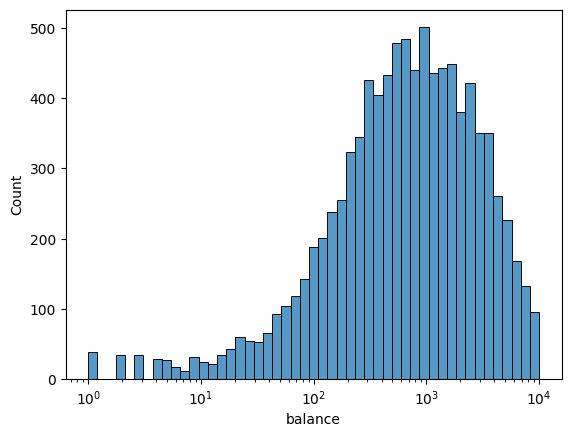

In [66]:
# Checking normalization
sns.histplot(data["balance"], log_scale=True)

In [67]:
# Bucketing balances
data["balance_group"] = pd.qcut(data["balance"], q=8)

# Since the target variable is binary,
# taking the mean of deposit within each balance group gives the conversion rate for that segment.
summary = data.groupby("balance_group")["deposit"].agg(["mean", "count"])
summary

/var/folders/yy/sflsldw51q153fp_63bn4ryh0000gn/T/ipykernel_9934/3365564754.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = data.groupby("balance_group")["deposit"].agg(["mean", "count"])


,mean,count
balance_group,,
"(-6847.001, 0.0]",0.343365,1462
"(0.0, 115.0]",0.372257,1276
"(115.0, 290.0]",0.442899,1366
"(290.0, 523.0]",0.479912,1369
"(523.0, 906.125]",0.474651,1361
"(906.125, 1595.0]",0.511679,1370
"(1595.0, 2987.0]",0.571848,1364
"(2987.0, 9994.0]",0.576867,1366


* People with higher balance have higher conversion rate

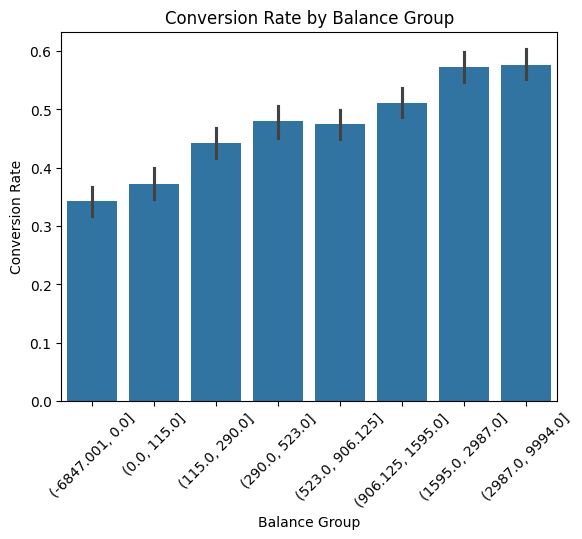

In [68]:
sns.barplot(x="balance_group", y="deposit", data=data)
plt.ylabel("Conversion Rate")
plt.xlabel("Balance Group")
plt.xticks(rotation=45)
plt.title("Conversion Rate by Balance Group")
plt.show()

In [69]:
# Job vs Conversion
jc_summary = data.groupby("job")["deposit"].agg(["mean", "count"])
jc_summary

,mean,count
job,,
admin.,0.469962,1315
blue-collar,0.364583,1920
entrepreneur,0.370717,321
housemaid,0.396296,270
management,0.503208,2494
retired,0.661397,759
self-employed,0.456410,390
services,0.400655,916
student,0.747875,353


* Management, Students and retired people have very high conversion rate

/var/folders/yy/sflsldw51q153fp_63bn4ryh0000gn/T/ipykernel_9934/3755847493.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="job", y="mean", data=jc_summary, palette="viridis")


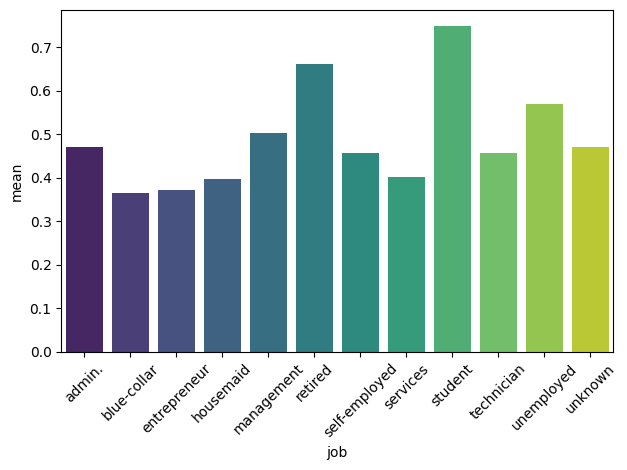

In [70]:
sns.barplot(x="job", y="mean", data=jc_summary, palette="viridis")
plt.xticks(rotation=45)
plt.tight_layout()

#### Which customers convert the most ?

In [71]:
# Balance group ~ job conversion rate. Pivot view
balance_job_conversion = data.groupby(["balance_group", "job"])["deposit"].mean().unstack()
balance_job_conversion

/var/folders/yy/sflsldw51q153fp_63bn4ryh0000gn/T/ipykernel_9934/2677490141.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_job_conversion = data.groupby(["balance_group", "job"])["deposit"].mean().unstack()


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
balance_group,,,,,,,,,,,,
"(-6847.001, 0.0]",0.356757,0.279503,0.471698,0.294118,0.294498,0.500000,0.354167,0.394366,0.687500,0.348739,0.375000,0.571429
"(0.0, 115.0]",0.398810,0.291667,0.250000,0.403846,0.380282,0.475410,0.409091,0.347458,0.666667,0.300518,0.555556,0.285714
"(115.0, 290.0]",0.516304,0.396078,0.234043,0.200000,0.498155,0.578947,0.339286,0.320312,0.777778,0.435685,0.425000,0.000000
"(290.0, 523.0]",0.433735,0.374468,0.375000,0.275862,0.520690,0.593023,0.500000,0.419580,0.771930,0.480519,0.673913,0.700000
"(523.0, 906.125]",0.461957,0.400000,0.382979,0.350000,0.503165,0.707317,0.473684,0.372340,0.775000,0.454128,0.547619,0.500000
"(906.125, 1595.0]",0.431034,0.356522,0.250000,0.500000,0.540984,0.767677,0.508772,0.458716,0.846154,0.520737,0.718750,0.500000
"(1595.0, 2987.0]",0.612903,0.436275,0.461538,0.645161,0.616715,0.711409,0.560000,0.476190,0.727273,0.542453,0.553191,0.500000
"(2987.0, 9994.0]",0.630769,0.420213,0.487179,0.437500,0.623656,0.732484,0.509434,0.441558,0.717391,0.565022,0.600000,0.333333


<Axes: xlabel='job', ylabel='balance_group'>

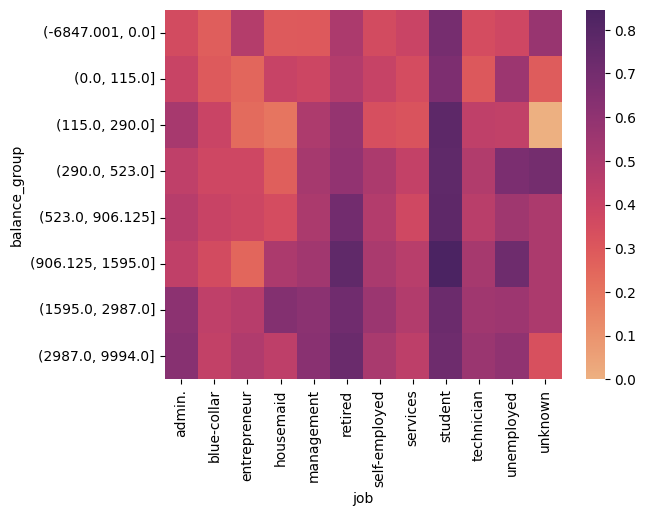

In [72]:
sns.heatmap(balance_job_conversion, cmap="flare")

Conversion based on a job and balance - tolerance > 60%
* All balance students
* Mid-High balance retired people
* High balance admins
* High balance housemaids
* High balance management workers 

In [73]:
# Previous campaing 
data.groupby("poutcome")["deposit"].mean()

poutcome
failure    0.502071
other      0.568401
success    0.913127
unknown    0.404674
Name: deposit, dtype: float64

Customers with previous successful campaigns are the most likely to convert

/var/folders/yy/sflsldw51q153fp_63bn4ryh0000gn/T/ipykernel_9934/3499284161.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.heatmap(data.groupby(['poutcome', 'balance_group'])['deposit'].mean().unstack(), cmap="flare")


<Axes: xlabel='balance_group', ylabel='poutcome'>

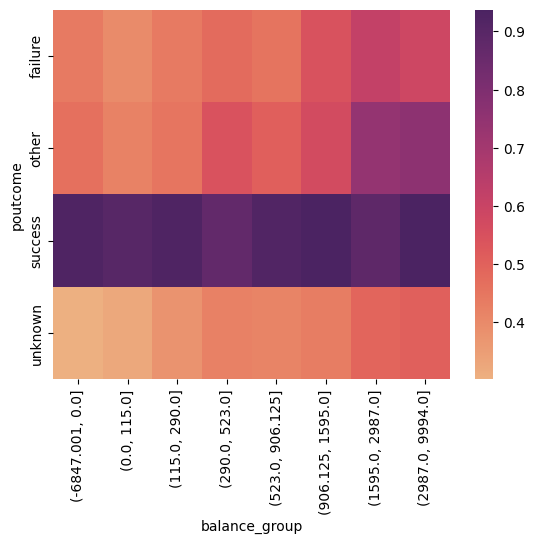

In [74]:
sns.heatmap(data.groupby(['poutcome', 'balance_group'])['deposit'].mean().unstack(), cmap="flare")

* According to the above heatmap, campaings with previous success status have very high conversion rates regardless of balance

In [75]:
# Age segmentation
data["age_group"] = pd.cut(data["age"], bins=[18,30,45,60,100])
data["age_group"]

0        (45, 60]
1        (45, 60]
2        (30, 45]
3        (45, 60]
4        (45, 60]
           ...   
11157    (30, 45]
11158    (30, 45]
11159    (30, 45]
11160    (30, 45]
11161    (30, 45]
Name: age_group, Length: 10934, dtype: category
Categories (4, interval[int64, right]): [(18, 30] < (30, 45] < (45, 60] < (60, 100]]

/var/folders/yy/sflsldw51q153fp_63bn4ryh0000gn/T/ipykernel_9934/4236768728.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.heatmap(data.groupby(["age_group", "balance_group"])["deposit"].mean().unstack(), cmap="flare")


<Axes: xlabel='balance_group', ylabel='age_group'>

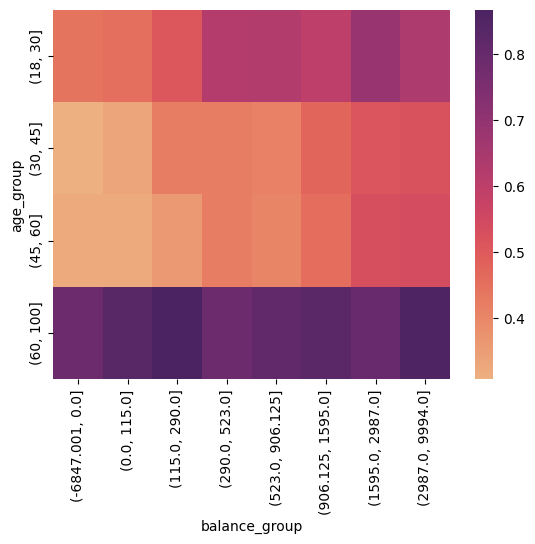

In [76]:
# Grouping by age group and balance group
sns.heatmap(data.groupby(["age_group", "balance_group"])["deposit"].mean().unstack(), cmap="flare")

* Age group [60,100] has very high conversion rate across all balance groups
* Ages 30-60 tend to convert only with higher balance
* Ages 18-30 tend to convert with mid-high balance

<Axes: xlabel='poutcome', ylabel='campaign'>

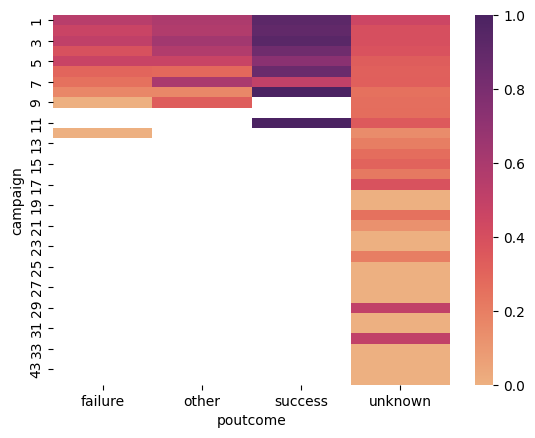

In [77]:
sns.heatmap(data.groupby(["campaign", "poutcome"])["deposit"].mean().unstack(), cmap="flare")

* Customers who had previous success campaigns tend to convert with less than 10-11 attempts (conversion > 70%)
* Customers who had previous failed campaigns tend to convert with less than 3 attempts (conversion > 50%)
* Conclusion: Fewer contacts = better conversion rate

In [78]:
# Months by conversion rates
pivot_months = data.groupby("month")["deposit"].agg(["mean", "count"])

# Proportions of amount of customers per month
pivot_months["proportion"] = (pivot_months["count"] / len(data)) * 100
pivot_months

,mean,count,proportion
month,,,
apr,0.621802,899,8.222060
aug,0.449090,1483,13.563197
dec,0.913462,104,0.951162
feb,0.564474,760,6.950796
jan,0.411079,343,3.137004
jul,0.412709,1495,13.672947
jun,0.447039,1199,10.965795
mar,0.895911,269,2.460216
may,0.325798,2787,25.489299


* Months have different proportions of customers


#### EDA Results (Business Insights)
* Which customers convert the most ?
    * High balance customers.
    * Customers with previous successfull campaing status.
    * Age group 60 to 100 with any balance.
    * Age group 18-30 with mid-high balance.
    * Customers with less than 10 contacted attempts if previous campaign was successful.
    * Customers with less than 3 contacted attempts if previous campaign was not successful.

* Does higher balance mean higher conversion ? 
    * Higher balance has a higher conversion rate in most cases.

* Which job type converts best ?
    * Students, retired and management people.

### Customer Response Model (Classification)

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10934 entries, 0 to 11161
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            10934 non-null  int64   
 1   job            10934 non-null  object  
 2   marital        10934 non-null  object  
 3   education      10934 non-null  object  
 4   default        10934 non-null  object  
 5   balance        10934 non-null  int64   
 6   housing        10934 non-null  object  
 7   loan           10934 non-null  object  
 8   contact        10934 non-null  object  
 9   day            10934 non-null  int64   
 10  month          10934 non-null  object  
 11  duration       10934 non-null  int64   
 12  campaign       10934 non-null  int64   
 13  pdays          10934 non-null  int64   
 14  previous       10934 non-null  int64   
 15  poutcome       10934 non-null  object  
 16  deposit        10934 non-null  int64   
 17  balance_group  10934 non-null  categ

In [80]:
# Categorical features
cat_features = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome", "balance_group", "age_group"]
df_cat = pd.get_dummies(data=data[cat_features], columns=cat_features, drop_first=True, dtype=int)


# Numerical features
num_features = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
df_num = data[num_features]

# Combining numeric + categorical (dummies)
X = pd.concat([df_num, df_cat], axis=1)

# Target variable
y = data["deposit"]

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [82]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/Users/davidarzumanyan/Documents/Python General Workspace Venv/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [83]:
# Evaluating the model
coef = pd.DataFrame({"Features" : model.feature_names_in_, "Coefficient" : model.coef_[0]})
coef.sort_values(by="Coefficient", ascending=False, inplace=True)
coef

,Features,Coefficient
40,poutcome_success,2.118263
34,month_mar,1.169585
37,month_oct,0.988429
51,"age_group_(60, 100]",0.795503
38,month_sep,0.721243
21,education_tertiary,0.532925
14,job_student,0.410387
33,month_jun,0.376246
44,"balance_group_(290.0, 523.0]",0.330195
47,"balance_group_(1595.0, 2987.0]",0.324402


In [84]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

predictions = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

y_pred_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC", roc_auc_score(y_test, y_pred_prob))


Accuracy:  0.8207863456263335
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1719
           1       0.82      0.80      0.81      1562

    accuracy                           0.82      3281
   macro avg       0.82      0.82      0.82      3281
weighted avg       0.82      0.82      0.82      3281

[[1450  269]
 [ 319 1243]]
ROC-AUC 0.896621252715936


In [85]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=300)
rfc.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
# Evaluating the RandomForestClassifier

rfc_predictions = rfc.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, rfc_predictions))
print(classification_report(y_test, rfc_predictions))
print(confusion_matrix(y_test, rfc_predictions))

y_pred_prob = rfc.predict_proba(X_test)[:, 1]
print("ROC-AUC", roc_auc_score(y_test, y_pred_prob))

Accuracy:  0.8405973788479122
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1719
           1       0.81      0.87      0.84      1562

    accuracy                           0.84      3281
   macro avg       0.84      0.84      0.84      3281
weighted avg       0.84      0.84      0.84      3281

[[1396  323]
 [ 200 1362]]
ROC-AUC 0.9090754533015428


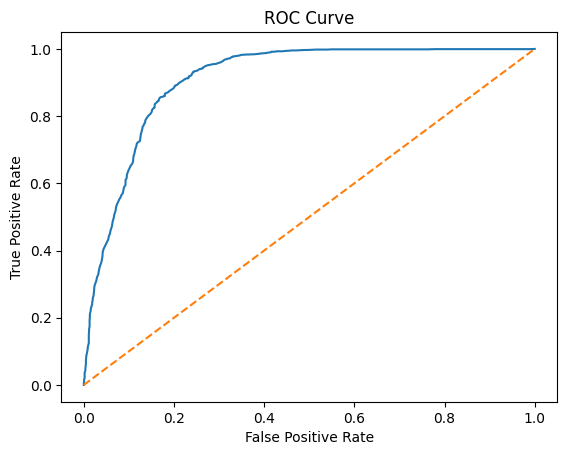

In [87]:
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [91]:
# Probability threshold tuning for Random Forest Classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.linspace(0, 1, 100)

results = []

for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([t, acc, prec, rec, f1])

# Converting into dataframe
tune_results_df = pd.DataFrame(results, columns=["threshold", "accuracy", "precision", "recall", "f1"])

/Users/davidarzumanyan/Documents/Python General Workspace Venv/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [92]:
tune_results_df

,threshold,accuracy,precision,recall,f1
0,0.000000,0.476074,0.476074,1.000000,0.645055
1,0.010101,0.494057,0.484783,0.999360,0.652865
2,0.020202,0.516001,0.495870,0.999360,0.662845
3,0.030303,0.544346,0.510966,0.999360,0.676197
4,0.040404,0.572996,0.527187,0.999360,0.690250
...,...,...,...,...,...
95,0.959596,0.542822,0.918919,0.043534,0.083130
96,0.969697,0.535507,0.931818,0.026248,0.051059
97,0.979798,0.529717,0.952381,0.012804,0.025268
98,0.989899,0.525450,1.000000,0.003201,0.006382


In [96]:
best_f1 = tune_results_df.loc[tune_results_df["f1"].idxmax()]
best_f1

threshold    0.373737
accuracy     0.839683
precision    0.775239
recall       0.934059
f1           0.847271
Name: 37, dtype: float64

In [ ]:
# We can however maximize any of the needed metrics (Depending on the business goal)
best_recall = tune_results_df.sort_values("recall", ascending=False).head()
best_precision = tune_results_df.sort_values("precision", ascending=False).head()

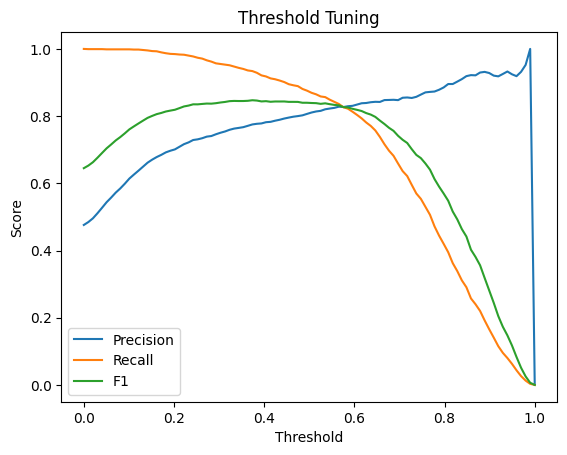

In [97]:
plt.plot(tune_results_df["threshold"], tune_results_df["precision"], label="Precision")
plt.plot(tune_results_df["threshold"], tune_results_df["recall"], label="Recall")
plt.plot(tune_results_df["threshold"], tune_results_df["f1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

In [101]:
# Creating new probabilities of classification based on the new threshold
best_threshold = 0.37
y_pred_prob_new = (y_pred_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_prob_new))
print("ROC-AUC", roc_auc_score(y_test, y_pred_prob_new))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83      1719
           1       0.77      0.93      0.85      1562

    accuracy                           0.84      3281
   macro avg       0.85      0.84      0.84      3281
weighted avg       0.85      0.84      0.84      3281

ROC-AUC 0.8428293330771024
